In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, ndcg_score
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

!pip install fastFM
from fastFM import sgd

In [34]:
tenders = pd.read_csv('preprocessed_full.csv')
suppliers = pd.read_excel('revenue_spark_final.xlsx')
tenders = tenders[tenders['year'] >= 2020]
data = tenders.merge(suppliers, on='ИНН поставщика', how='left')

In [37]:
data = data.drop(columns=['Сводный риск_y', 'Выручка_y'])
data = data.dropna(subset=['win_rate'])
data['Отрасль'] = data['Отрасль'].fillna("Неизвестно")
data = data.dropna(subset=['Адрес'])

In [38]:
data.isna().sum()

,0
Unnamed: 0,0
Уровень,0
Заказчик,0
ИНН заказчика,0
Стоимость(руб.) Заказчик,0
Реестровый номер публикации,0
Сфера деятельности,0
Регион поставки,0
Город поставки,0
Дата публикации,0


In [39]:
data['Дата публикации'] = pd.to_datetime(data['Дата публикации'], format='mixed')

Заполним все пропуски в Персонале через IterativeImputer

In [40]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor


imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=42, bootstrap=True), max_iter=10, verbose=2)
data[['Персонал']] = imputer.fit_transform(data[['Персонал']])

In [41]:
use_sample = True
sample_size = 100000
if use_sample and len(data) > sample_size:
    print(f"Using sample of {sample_size} rows")
    data = data.sample(n=sample_size, random_state=42)

def create_features(df, feature_config):
    """Создает матрицу признаков на основе конфигурации."""
    print(f"Creating features with config: {feature_config['name']}")
    features_list = []

    if feature_config.get('use_cat_event', False):
        cat_cols = ['ИНН заказчика', 'Регион поставки', 'Город поставки', 'Тип торгов']
        cat_cols = [col for col in cat_cols if col in df.columns]
        if cat_cols:
            ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
            X_cat = ohe.fit_transform(df[cat_cols].astype(str))
            features_list.append(X_cat)
            print(f"Added categorical event features: {X_cat.shape}")
        else:
             print("No categorical event columns found.")


    if feature_config.get('use_text_event', False):
        if 'Сфера деятельности' in df.columns:
            tf = CountVectorizer(min_df=3)
            X_text = tf.fit_transform(df['Сфера деятельности'])
            features_list.append(X_text)
            print(f"Added text event features: {X_text.shape}")
        else:
            print("Column 'Сфера деятельности' not found.")

    if feature_config.get('use_num_event', False):
        num_cols = [
            "avg_price_drop", "log_cost", "log_profit", "Снижение на торгах,%",
            'win_rate', 'region_win_rate', 'customer_win_rate', 'sphere_win_rate',
            "days_between", "region_wins", "customer_wins", "sphere_wins",
            "total_wins", "competitors_per_tender", "avg_competitors_in_region",
            "avg_competitors_in_sphere", "avg_competitors_in_customer",
            "Обеспечение заявки (руб.)", "Обеспечение заявки, %",
            "Обеспечение контракта (руб.)", "Обеспечение контракта, %",
            "РНП ранее", "is_january", "publication_peak_9_11", "app_end_noon_12",
            "app_start_night_12", "trade_end_night_12", "is_2019", "is_jan_to_april",
            "Статус допуска"
        ]
        num_cols = [col for col in num_cols if col in df.columns]
        if num_cols:
             X_num = csr_matrix(df[num_cols].values)
             features_list.append(X_num)
             print(f"Added numerical event features: {X_num.shape}")
        else:
            print("No numerical event columns found.")


    # Числовые признаки поставщика
    if feature_config.get('use_num_supplier', False):
        sup_num_cols = ['Выручка_x', 'Персонал', 'Сводный риск_x']
        sup_num_cols = [col for col in sup_num_cols if col in df.columns]
        if sup_num_cols:
            X_sup_num = csr_matrix(df[sup_num_cols].values)
            features_list.append(X_sup_num)
            print(f"Added numerical supplier features: {X_sup_num.shape}")
        else:
            print("No numerical supplier columns found.")


    # Текстовые признаки поставщика
    if feature_config.get('use_text_supplier', False):
        if 'Отрасль' in df.columns:
            sup_tf = CountVectorizer(min_df=3)
            X_sup_text = sup_tf.fit_transform(df['Отрасль'])
            features_list.append(X_sup_text)
            print(f"Added text supplier features: {X_sup_text.shape}")
        else:
             print("Column 'Отрасль' not found.")

    # Идентификатор поставщика как признак (OneHotEncoded)
    if feature_config.get('use_supplier_id', False):
        if 'ИНН поставщика' in df.columns:
            supplier_ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
            X_sup_id = supplier_ohe.fit_transform(df[['ИНН поставщика']].astype(str))
            features_list.append(X_sup_id)
            print(f"Added supplier ID features: {X_sup_id.shape}")
        else:
            print("Column 'ИНН поставщика' not found.")

    if not features_list:
        return csr_matrix((df.shape[0], 0))

    X = hstack(features_list).tocsr()
    print(f"Total features shape: {X.shape}")
    return X

In [42]:
def evaluate_rankings(df_test_fold, score_col, k_list):
    results = {k: {'precision': [], 'recall': [], 'ndcg': []} for k in k_list}

    for tender_id, group in df_test_fold.groupby('Реестровый номер публикации'):
        group = group.dropna(subset=[score_col])
        sorted_group = group.sort_values(score_col, ascending=False)
        y_true = sorted_group['Победитель'].values
        y_score = sorted_group[score_col].values
        if len(y_true) < 2:
            for k in k_list:
                results[k]['precision'].append(np.nan)
                results[k]['recall'].append(np.nan)
                results[k]['ndcg'].append(np.nan)
            continue

        if y_true.sum() == 0:
            for k in k_list:
                results[k]['precision'].append(0.0)
                results[k]['recall'].append(0.0)
                results[k]['ndcg'].append(0.0)
            continue
        for k in k_list:
            top_k_indices = sorted_group.index[:k]
            y_pred_topk = y_true[:k]
            # Precision@k: Доля релевантных среди топ-k рекомендованных
            p_k = y_pred_topk.sum() / k
            results[k]['precision'].append(p_k)

            # Recall@k: Доля релевантных среди топ-k от всех релевантных
            r_k = y_pred_topk.sum() / y_true.sum()
            results[k]['recall'].append(r_k)
            ndcg_k = ndcg_score(y_true.reshape(1, -1), y_score.reshape(1, -1), k=k)
            results[k]['ndcg'].append(ndcg_k)

    avg_results = {
        k: {metric: np.nanmean(values) for metric, values in metrics.items()}
        for k, metrics in results.items()
    }
    return avg_results

In [43]:
feature_configs = [
    {
        'name': 'Minimal (SupplierID only)', # Только ID поставщика - похоже на коллаборативную фильтрацию
        'use_cat_event': False,
        'use_text_event': False,
        'use_num_event': False,
        'use_num_supplier': False,
        'use_text_supplier': False,
        'use_supplier_id': True,
    },
    {
        'name': 'Event Info (Cat+Text+Num)', # Только информация о событии
        'use_cat_event': True,
        'use_text_event': True,
        'use_num_event': True,
        'use_num_supplier': False,
        'use_text_supplier': False,
        'use_supplier_id': False, # Без ID поставщика - контентная модель
    },
    {
        'name': 'Event + Supplier Info (No ID)', # Информация о событии и поставщике, но без ID
        'use_cat_event': True,
        'use_text_event': True,
        'use_num_event': True,
        'use_num_supplier': True,
        'use_text_supplier': True,
        'use_supplier_id': False,
    },
     {
        'name': 'Full (Event + Supplier + ID)', # Все признаки, включая ID поставщика
        'use_cat_event': True,
        'use_text_event': True,
        'use_num_event': True,
        'use_num_supplier': True,
        'use_text_supplier': True,
        'use_supplier_id': True,
    }
]

Подберем гиперпараметры

In [ ]:
from sklearn.model_selection import train_test_split
from itertools import product


N_SPLITS = 2
gkf = GroupKFold(n_splits=N_SPLITS)
groups = data['Реестровый номер публикации']
y = data['Победитель'].values


param_grid = {
    'rank':      [4, 8, 16, 32],
    'n_iter':    [50, 100, 200],
    'l2_reg_w':  [1e-4, 1e-2, 1e-5, 0.1],
    'l2_reg_V':  [1e-4, 1e-2, 1e-5, 0.1],
}

results = []

for config in feature_configs:
    print(f"\n===== Feature Set: {config['name']} =====")
    X_full = create_features(data, config)
    if X_full.shape[1] == 0:
        print("Empty feature matrix, skipping.")
        continue

    fold = 0
    for tr_idx, te_idx in gkf.split(X_full, y, groups):
        fold += 1
        print(f"\n-- Fold {fold}/{N_SPLITS} --")
        X_tr, X_te = X_full[tr_idx], X_full[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        df_te = data.iloc[te_idx].copy()

        tr_inner, val_inner = train_test_split(
            np.arange(len(tr_idx)),
            test_size=0.2,
            random_state=42,
            stratify=y_tr
        )
        X_tr_i = X_tr[tr_inner]
        y_tr_i = y_tr[tr_inner]
        X_val_i = X_tr[val_inner]
        y_val_i = y_tr[val_inner]
        df_val = data.iloc[tr_idx[val_inner]].copy()
        y_tr_i_fm = np.where(y_tr_i == 0, -1, y_tr_i)
        y_tr_i_fm = np.ascontiguousarray(y_tr_i_fm, dtype=np.float64)

        best = {'ndcg': -np.inf}
        for rank, n_iter, l2w, l2V in product(
                param_grid['rank'],
                param_grid['n_iter'],
                param_grid['l2_reg_w'],
                param_grid['l2_reg_V']):
            fm = sgd.FMClassification(
                rank=rank, n_iter=n_iter,
                l2_reg_w=l2w, l2_reg_V=l2V,
                init_stdev=0.1, random_state=42
            )
            fm.fit(X_tr_i, y_tr_i_fm)
            scores_val = fm.predict_proba(X_val_i)
            df_val_copy = df_val.copy()
            df_val_copy['score_fm'] = scores_val
            ndcg10 = evaluate_rankings(df_val_copy, 'score_fm', [10])[10]['ndcg']
            if ndcg10 > best['ndcg']:
                best = {'rank': rank, 'n_iter': n_iter,
                        'l2w': l2w, 'l2V': l2V, 'ndcg': ndcg10}
        print(" Best params:", best)

        y_tr_fm = np.where(y_tr == 0, -1, y_tr)
        y_tr_fm = np.ascontiguousarray(y_tr_fm, dtype=np.float64)
        fm_final = sgd.FMClassification(
            rank=best['rank'], n_iter=best['n_iter'],
            l2_reg_w=best['l2w'], l2_reg_V=best['l2V'],
            init_stdev=0.1, random_state=42
        )
        fm_final.fit(X_tr, y_tr_fm)

        scores_test = fm_final.predict_proba(X_te)
        df_te['score_fm'] = scores_test
        metrics = evaluate_rankings(df_te, 'score_fm', [1, 3, 5, 10, 20])

        for k, m in metrics.items():
            results.append({
                'feature_set': config['name'],
                'fold': fold,
                'k': k,
                'precision': m['precision'],
                'recall': m['recall'],
                'ndcg': m['ndcg']
            })
        print(f" Fold {fold} metrics:", metrics)

results_df = pd.DataFrame(results)
agg = results_df.groupby(['feature_set', 'k']).agg(
    precision_mean=('precision', 'mean'),
    recall_mean=('recall', 'mean'),
    ndcg_mean=('ndcg', 'mean')
).reset_index()

print("\n=== Aggregated Results ===")
print(agg)


In [44]:
from fastFM import mcmc

N_SPLITS = 5

gkf = GroupKFold(n_splits=N_SPLITS)
print(f"Using GroupKFold with {N_SPLITS} splits.")
groups = data['Реестровый номер публикации']


results_list = []
ks = [1, 3, 5, 10, 20]


y = data['Победитель'].values
for config in feature_configs:
    start_time_config = time.time()
    X = create_features(data, config)

    if X.shape[1] == 0:
        print(f"Skipping config '{config['name']}' due to empty feature matrix.")
        continue

    fold_num = 0
    for tr_idx, te_idx in gkf.split(X, y, groups):
        fold_num += 1
        start_time_fold = time.time()
        print(f"\n--- Feature Set: '{config['name']}', Fold: {fold_num}/{N_SPLITS} ---")

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        df_te_fold = data.iloc[te_idx].copy() # Копия данных тестового фолда для evaluate

        print(f"Train size: {X_tr.shape[0]}, Test size: {X_te.shape[0]}")
        if X_tr.shape[0] == 0 or X_te.shape[0] == 0:
              print("Skipping fold due to empty train or test set.")
              continue

        models_to_run = {
                'Popularity': None,
                'LogisticRegression': LogisticRegression(max_iter=200, solver='liblinear', random_state=42), # liblinear часто быстрее на разреженных данных
                'fastFM_Classification': mcmc.FMClassification(
                    n_iter=500,
                    rank=4,
                    init_stdev=0.1,
                    random_state=42
                )
          }

        for model_name, model in models_to_run.items():
                print(f"Running model: {model_name}")
                model_start_time = time.time()
                scores = np.zeros(len(df_te_fold))
                if model_name == 'Popularity':
                      supplier_win_rate = data.iloc[tr_idx].groupby('ИНН поставщика')['Победитель'].mean()
                      scores = df_te_fold['ИНН поставщика'].map(supplier_win_rate).fillna(0).values
                elif model is not None:
                      if model_name == 'fastFM_Classification':
                          y_tr_fm = np.where(y_tr == 0, -1, y_tr)
                          y_tr_fm = np.ascontiguousarray(y_tr_fm, dtype=np.float64)
                          #model.fit_predict(X_tr, y_tr_fm, X_te)
                      else:
                          model.fit(X_tr, y_tr)

                      if model_name != 'fastFM_Classification':
                          scores = model.predict_proba(X_te)[:, 1]
                      else:
                          scores = model.fit_predict_proba(X_tr, y_tr_fm, X_te)


                df_te_fold[f'score_{model_name}'] = scores
                eval_metrics = evaluate_rankings(df_te_fold, f'score_{model_name}', ks)

                for k, metrics in eval_metrics.items():
                    results_list.append({
                            'feature_set': config['name'],
                            'fold': fold_num,
                            'model': model_name,
                            'k': k,
                            'precision': metrics['precision'],
                            'recall': metrics['recall'],
                            'ndcg': metrics['ndcg']
                    })
                print(f"  {model_name} evaluated in {time.time() - model_start_time:.2f} sec")
                print(f"  Metrics @{ks[-1]}: P={eval_metrics[ks[-1]]['precision']:.4f}, R={eval_metrics[ks[-1]]['recall']:.4f}, NDCG={eval_metrics[ks[-1]]['ndcg']:.4f}")

        print(f"Fold {fold_num} completed in {time.time() - start_time_fold:.2f} sec")

    print(f"Feature set '{config['name']}' completed in {time.time() - start_time_config:.2f} sec")

Using GroupKFold with 5 splits.
Creating features with config: Minimal (SupplierID only)
Added supplier ID features: (98036, 37127)
Total features shape: (98036, 37127)

--- Feature Set: 'Minimal (SupplierID only)', Fold: 1/5 ---
Train size: 78428, Test size: 19608
Running model: Popularity
  Popularity evaluated in 29.63 sec
  Metrics @20: P=0.0549, R=0.9537, NDCG=0.7571
Running model: LogisticRegression
  LogisticRegression evaluated in 29.61 sec
  Metrics @20: P=0.0548, R=0.9537, NDCG=0.7559
Running model: fastFM_Classification
  fastFM_Classification evaluated in 54.75 sec
  Metrics @20: P=0.0549, R=0.9538, NDCG=0.7555
Fold 1 completed in 114.03 sec

--- Feature Set: 'Minimal (SupplierID only)', Fold: 2/5 ---
Train size: 78429, Test size: 19607
Running model: Popularity
  Popularity evaluated in 30.82 sec
  Metrics @20: P=0.0532, R=0.9473, NDCG=0.7495
Running model: LogisticRegression
  LogisticRegression evaluated in 30.11 sec
  Metrics @20: P=0.0532, R=0.9473, NDCG=0.7497
Running

In [45]:
results_df = pd.DataFrame(results_list)
agg_results = results_df.groupby(['feature_set', 'model', 'k']).agg(
        precision_mean=('precision', 'mean'),
        precision_std=('precision', 'std'),
        recall_mean=('recall', 'mean'),
        recall_std=('recall', 'std'),
        ndcg_mean=('ndcg', 'mean'),
        ndcg_std=('ndcg', 'std')
).reset_index()

print("\n--- Aggregated Results (Mean over folds) ---")
print(agg_results)


--- Aggregated Results (Mean over folds) ---
                      feature_set                  model   k  precision_mean  \
0   Event + Supplier Info (No ID)     LogisticRegression   1        0.401547   
1   Event + Supplier Info (No ID)     LogisticRegression   3        0.303897   
2   Event + Supplier Info (No ID)     LogisticRegression   5        0.200663   
3   Event + Supplier Info (No ID)     LogisticRegression  10        0.105151   
4   Event + Supplier Info (No ID)     LogisticRegression  20        0.053305   
5   Event + Supplier Info (No ID)             Popularity   1        0.496542   
6   Event + Supplier Info (No ID)             Popularity   3        0.311242   
7   Event + Supplier Info (No ID)             Popularity   5        0.202221   
8   Event + Supplier Info (No ID)             Popularity  10        0.105383   
9   Event + Supplier Info (No ID)             Popularity  20        0.053325   
10  Event + Supplier Info (No ID)  fastFM_Classification   1        0.4055

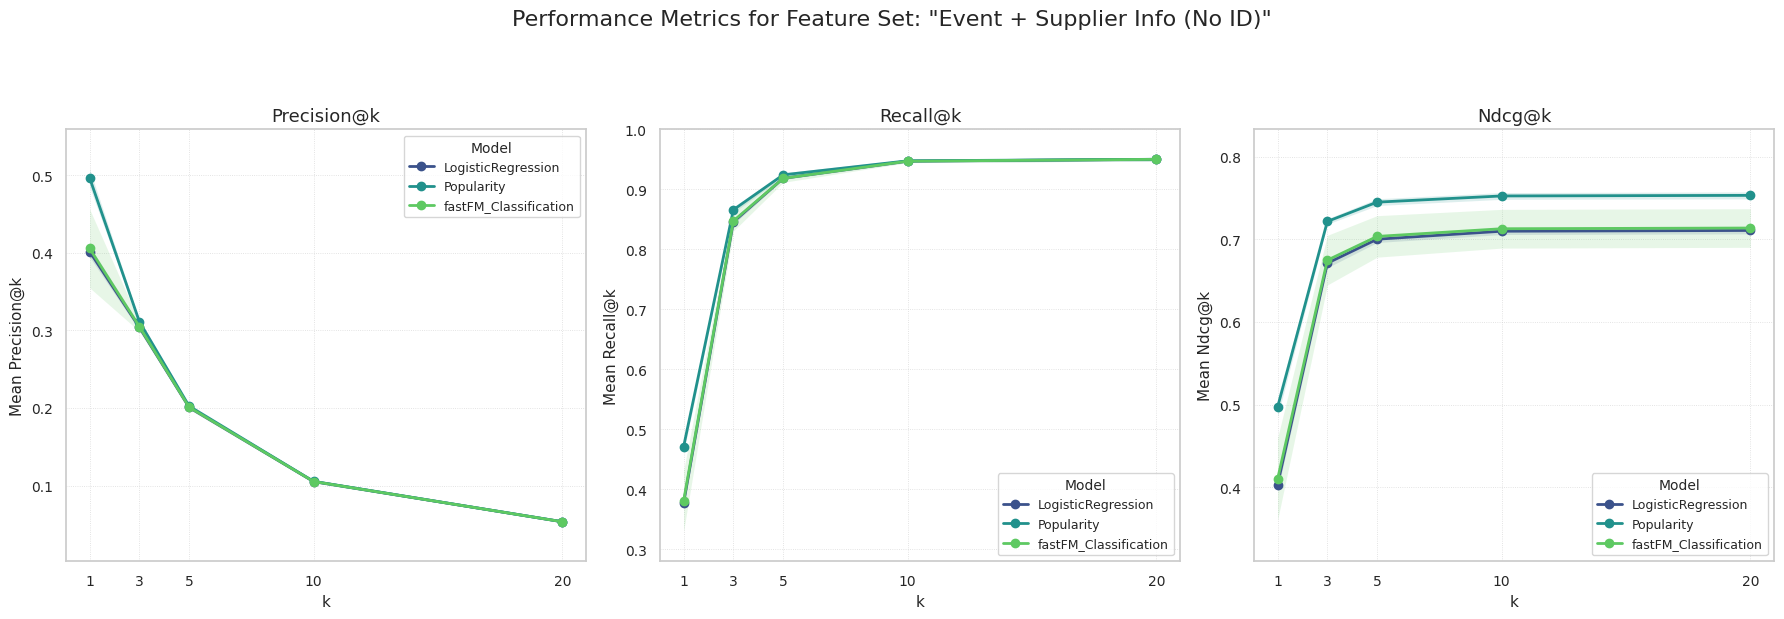

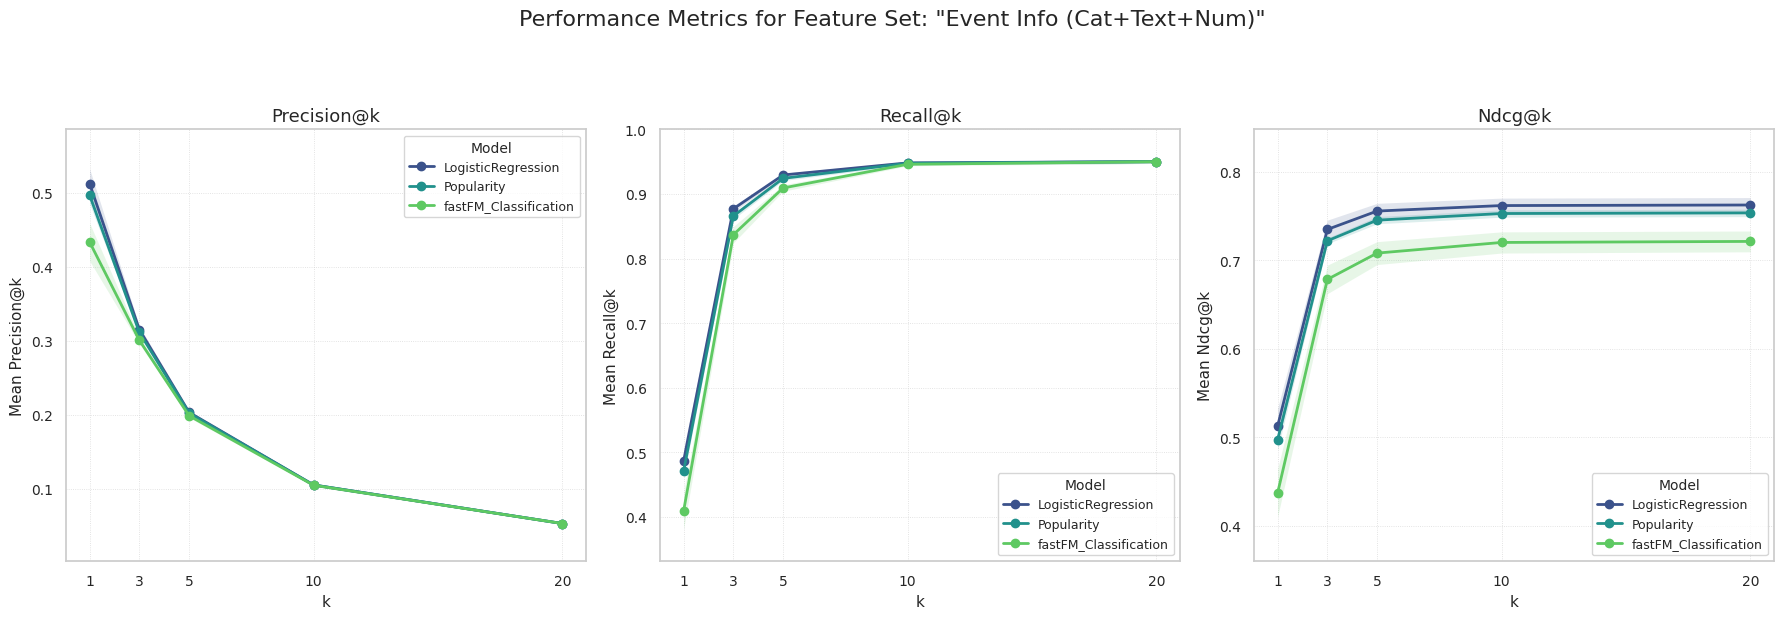

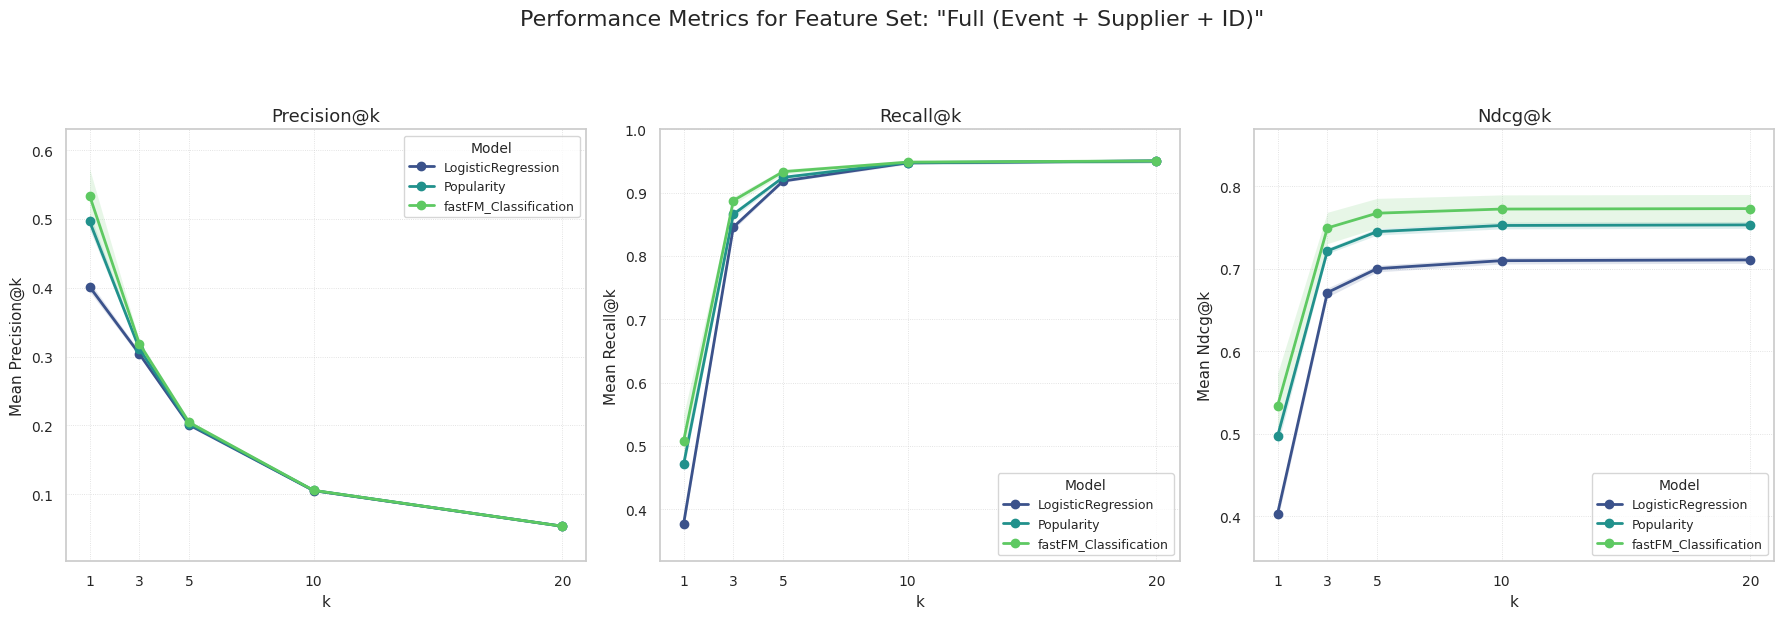

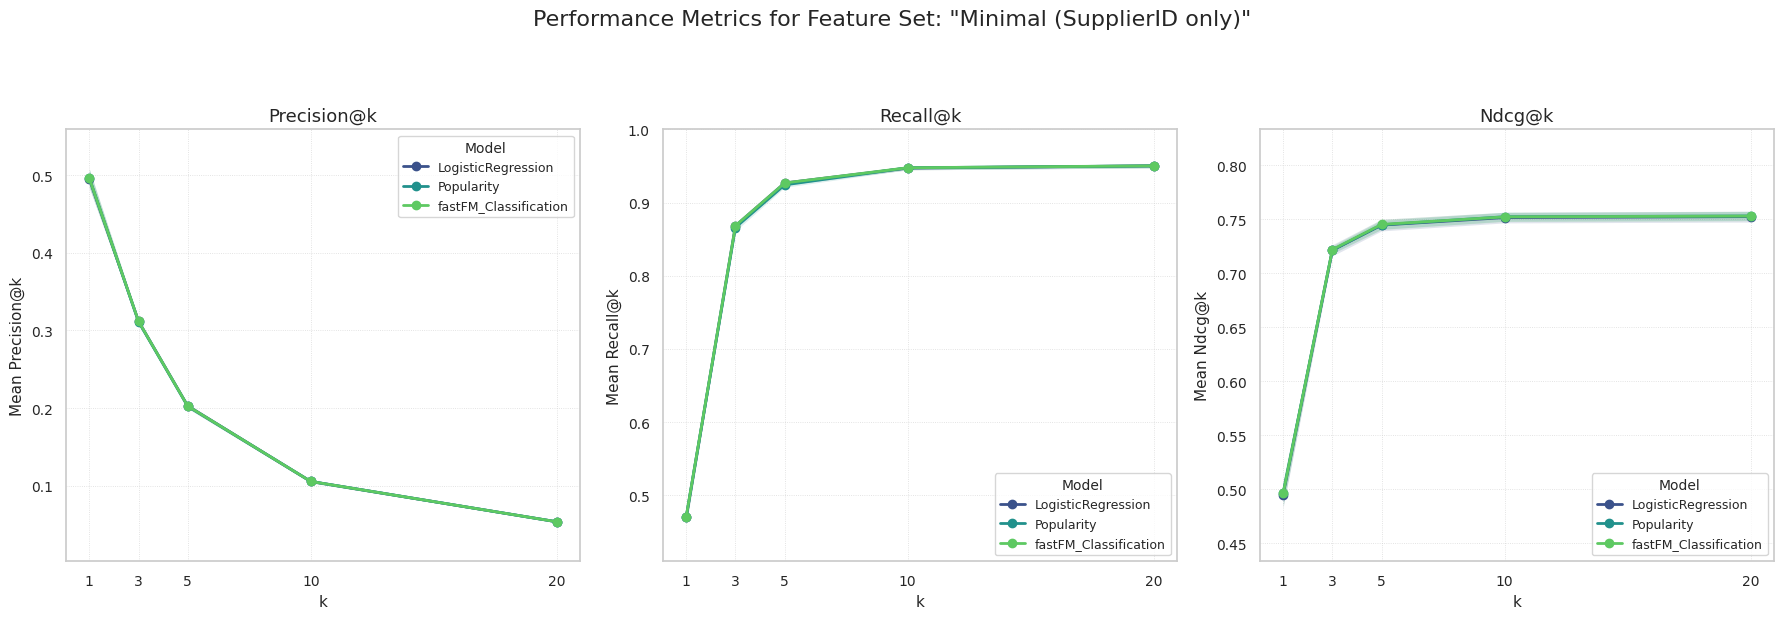

In [48]:
import seaborn as sns

sns.set_theme(style="whitegrid")

metrics_to_plot = ['precision', 'recall', 'ndcg']
feature_sets = agg_results['feature_set'].unique()
models = agg_results['model'].unique()

palette = sns.color_palette("viridis", n_colors=len(models))

model_colors = dict(zip(models, palette))

for fset in feature_sets:
    plt.figure(figsize=(18, 6))
    df_fset = agg_results[agg_results['feature_set'] == fset].copy()
    df_fset.sort_values(by='k', inplace=True)
    k_values = df_fset['k'].unique()


    for i, metric in enumerate(metrics_to_plot):
        ax = plt.subplot(1, len(metrics_to_plot), i+1)
        max_y_value = (df_fset[f'{metric}_mean'] + df_fset[f'{metric}_std']).max() if not df_fset.empty else 0
        min_y_value = (df_fset[f'{metric}_mean'] - df_fset[f'{metric}_std']).min() if not df_fset.empty else 0


        for model in models:
            df_model = df_fset[df_fset['model'] == model]
            if not df_model.empty:
                  color = model_colors[model]
                  ax.plot(df_model['k'], df_model[f'{metric}_mean'],
                          marker='o',
                          linestyle='-',
                          linewidth=2,
                          label=model,
                          color=color)

                  ax.fill_between(df_model['k'],
                                   df_model[f'{metric}_mean'] - df_model[f'{metric}_std'],
                                   df_model[f'{metric}_mean'] + df_model[f'{metric}_std'],
                                   alpha=0.15,
                                   color=color,
                                   linewidth=0)

        ax.set_xlabel('k', fontsize=11)
        ax.set_ylabel(f'Mean {metric.capitalize()}@k', fontsize=11)
        ax.set_title(f'{metric.capitalize()}@k', fontsize=13)

        ax.set_xticks(k_values)
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.set_ylim(bottom=max(0, min_y_value - 0.05) , top=min(1.0, max_y_value * 1.1) if max_y_value > 0 else 0.1)
        ax.legend(title='Model', fontsize=9, title_fontsize=10, frameon=True, facecolor='white', framealpha=0.8)

        ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)


    plt.suptitle(f'Performance Metrics for Feature Set: "{fset}"', fontsize=16, y=1.03)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


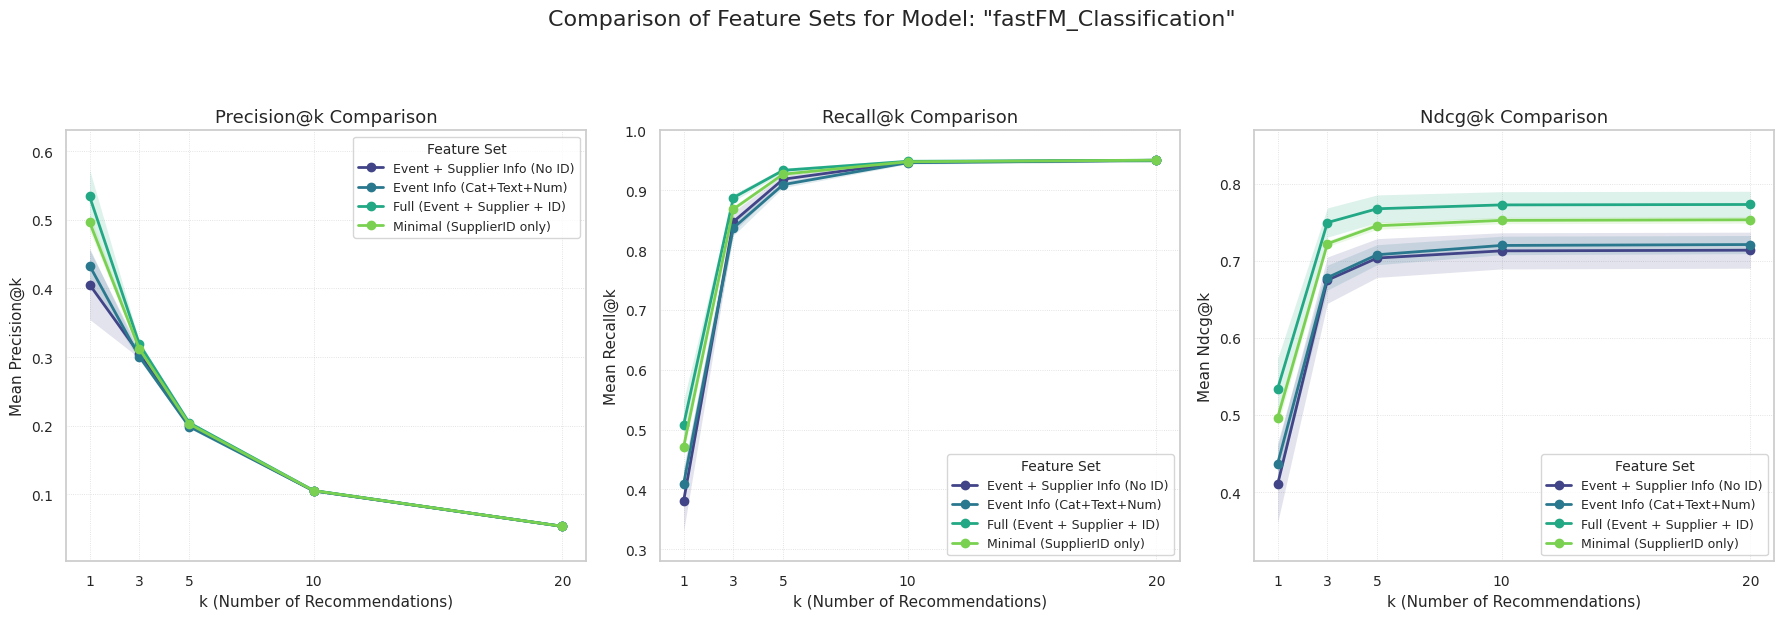

In [52]:
sns.set_theme(style="whitegrid")

model_to_compare = 'fastFM_Classification'
df_model_focus = agg_results[agg_results['model'] == model_to_compare].copy()
palette = sns.color_palette("viridis", n_colors=len(feature_sets))
fset_colors = dict(zip(feature_sets, palette))
plt.figure(figsize=(18, 6))

k_values = df_model_focus['k'].unique()
df_model_focus.sort_values(by='k', inplace=True)

for i, metric in enumerate(metrics_to_plot):
    ax = plt.subplot(1, len(metrics_to_plot), i+1)
    max_y_value = (df_model_focus[f'{metric}_mean'] + df_model_focus[f'{metric}_std']).max() if not df_model_focus.empty else 0
    min_y_value = (df_model_focus[f'{metric}_mean'] - df_model_focus[f'{metric}_std']).min() if not df_model_focus.empty else 0

    for fset in feature_sets:
        df_comp = df_model_focus[df_model_focus['feature_set'] == fset]
        df_comp = df_comp.sort_values(by='k')
        color = fset_colors[fset]
        ax.plot(df_comp['k'], df_comp[f'{metric}_mean'],
                marker='o',
                linestyle='-',
                linewidth=2,
                label=fset,
                color=color)

        ax.fill_between(df_comp['k'],
                        df_comp[f'{metric}_mean'] - df_comp[f'{metric}_std'],
                        df_comp[f'{metric}_mean'] + df_comp[f'{metric}_std'],
                        alpha=0.15,
                        color=color,
                        linewidth=0)

    ax.set_xlabel('k (Number of Recommendations)', fontsize=11)
    ax.set_ylabel(f'Mean {metric.capitalize()}@k', fontsize=11)
    ax.set_title(f'{metric.capitalize()}@k Comparison', fontsize=13)

    ax.set_xticks(k_values)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_ylim(bottom=max(0, min_y_value - 0.05) , top=min(1.0, max_y_value * 1.1) if max_y_value > 0 else 0.1)
    ax.legend(title='Feature Set', fontsize=9, title_fontsize=10, frameon=True, facecolor='white', framealpha=0.8)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)

plt.suptitle(f'Comparison of Feature Sets for Model: "{model_to_compare}"', fontsize=16, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
